# 13 — APS: dual size distributions

**Theme:** an instrument that sizes the same particle two different ways at
once.

The TSI Aerodynamic Particle Sizer measures an **aerodynamic** diameter, from
how a particle accelerates in a flow, and an **optical** diameter, from how much
light it scatters. The two differ in a way that depends on particle shape and
refractive index — so comparing them says something about what the particles
*are*, not just how large they are.

An APS export therefore loads as `Aerosol3d`: two size distributions over time,
plus the correlation between them.

In [1]:
import matplotlib.pyplot as plt

import aerosoltools as at

aps = at.load_aps_file("../../tests/data/Sample_APS_correlated.txt")

print("type         :", type(aps).__name__)
print("is_correlated:", aps.is_correlated)

type         : Aerosol3d
is_correlated: True


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`is_correlated` distinguishes the two kinds of export. A correlated file carries
both axes and the joint distribution; an aerodynamic-only file loads as a plain
`Aerosol2D`, because there is no second axis to pair with.

In [2]:
aero_only = at.load_aps_file("../../tests/data/Sample_APS_aero.txt")
print("aerodynamic-only export loads as:", type(aero_only).__name__)

aerodynamic-only export loads as: Aerosol2D


## The two axes

Each axis is available as an ordinary size-resolved dataset, so everything from
the earlier notebooks works on it. Note that they do not share a bin structure:
the two sizing principles have different resolutions and cover different ranges.

In [3]:
print(f"aerodynamic: {len(aps.aerodynamic.bin_mids):2d} bins, "
      f"{aps.aerodynamic.bin_mids.min():7.1f} - {aps.aerodynamic.bin_mids.max():8.1f} nm")
print(f"optical    : {len(aps.optical.bin_mids):2d} bins, "
      f"{aps.optical.bin_mids.min():7.1f} - {aps.optical.bin_mids.max():8.1f} nm")

aerodynamic: 52 bins,   514.5 -  19810.0 nm
optical    : 16 bins,   561.1 -  17822.4 nm


## Comparing the two distributions

Drawing both on one axes needs a colour per dataset. `plot_psd` normally
colours by *activity*, so two datasets would otherwise come out the same colour
and read as a single line doubling back on itself. Pass `color` and `label` to
name the dataset instead.

The shaded band around each curve is ±1 standard deviation across time, not an
uncertainty on the mean.

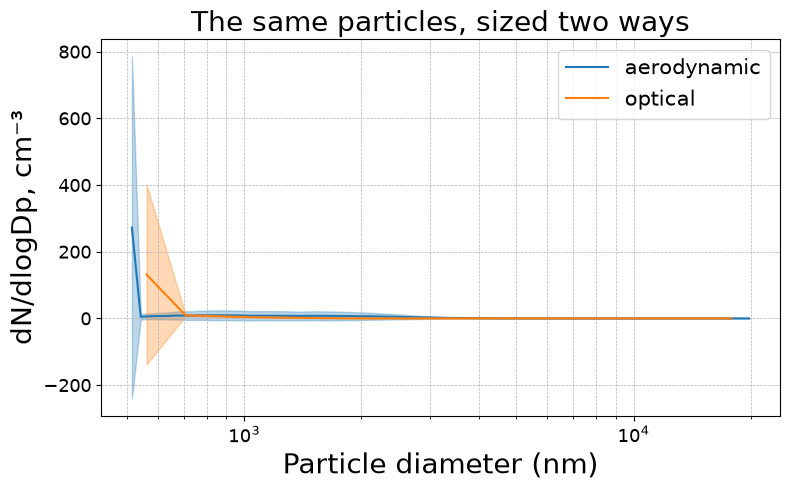

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

aps.aerodynamic.plot_psd(ax=ax, activities=["All data"],
                         color="tab:blue", label="aerodynamic")
aps.optical.plot_psd(ax=ax, activities=["All data"],
                     color="tab:orange", label="optical")

ax.set_xscale("log")
ax.set_title("The same particles, sized two ways")
ax.legend(loc="upper right")
plt.tight_layout()

The separation between the curves is the physical signal. For spherical
particles of known refractive index the two sizings agree; they diverge as
particles become irregular, porous, or optically unusual. The optical
distribution here is both coarser and narrower, which is what a small number of
wide bins produces.

## Working with one axis

`as_2d` returns an independent copy of one axis — modify it freely without
touching the parent.

In [5]:
standalone = aps.as_2d("aerodynamic")
print(type(standalone).__name__, "with", len(standalone.bin_mids), "bins")

Aerosol2D with 52 bins


`axis_view` returns a *live* view instead, with activities kept in sync with the
parent. Use `axis_view` when you want marked activities to follow, and `as_2d`
when you want an independent object.

In [6]:
view = aps.axis_view("optical")
print(type(view).__name__, "- activities stay synced with the parent")

Aerosol2D - activities stay synced with the parent


## The instrument's own comparison

`plot_aero_vs_optical` shows the relationship between the two diameters
directly, rather than as two separate distributions.

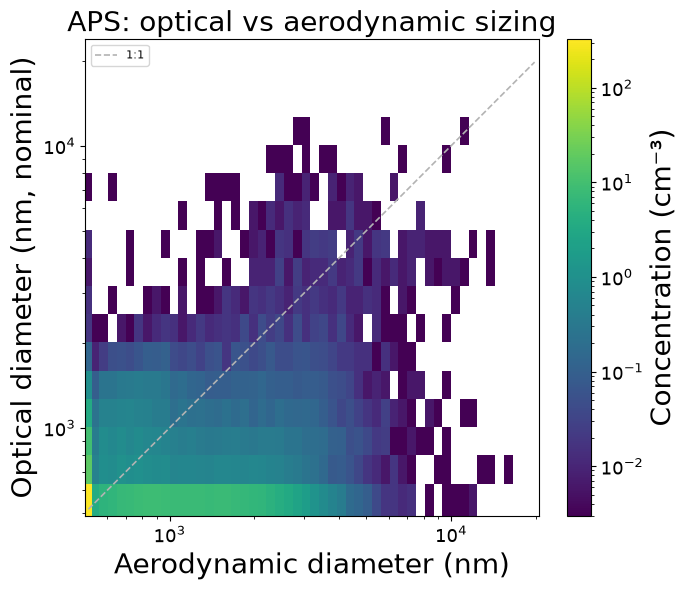

In [7]:
fig, ax = aps.plot_aero_vs_optical()

## The joint distribution

For each time step the instrument records how many particles fell in each
(aerodynamic, optical) pair of bins. `correlation_cube` returns that as a dense
time × optical × aerodynamic array.

In [8]:
cube = aps.correlation_cube()
print("type:", type(cube).__name__)

type: CorrelationCube


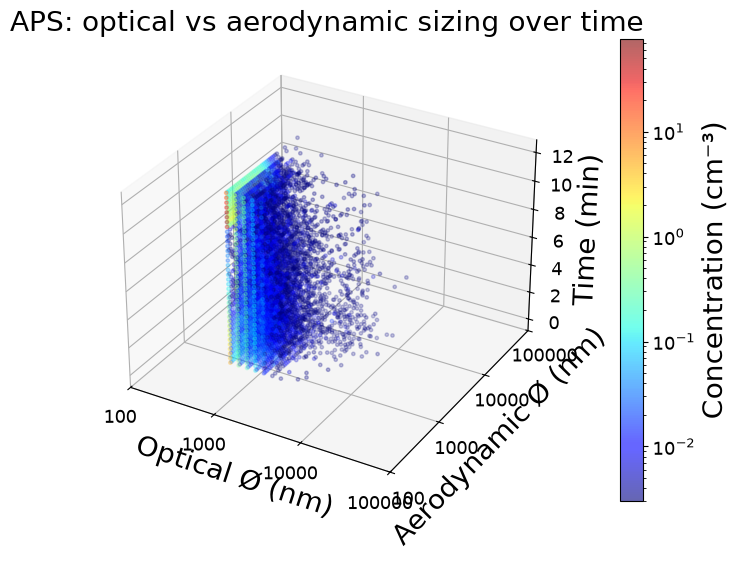

In [9]:
fig, ax = aps.plot_aero_optical_3d()

This is what makes an APS more than two instruments in a box: it records which
optical size each aerodynamically-sized particle had, rather than giving two
independent histograms that happen to cover the same air.

## Summaries

Because each axis is a normal size-resolved dataset, mass fractions, statistics
and exposure metrics all work per axis.

In [10]:
aps.aerodynamic.summarize_activities(metrics=["PNC"], stats=["mean", "median", "max"])


Summary of aerosol properties (transposed):

+-------------------+----------+
|                   | All data |
+-------------------+----------+
| Duration (HH:MM)  |  00:12   |
|    PNC [cm⁻³]     |  15.19   |
| PNC [cm⁻³] median |   3.02   |
|  PNC [cm⁻³] max   |  117.71  |
+-------------------+----------+


,Segment,Duration (HH:MM),PNC [cm⁻³],PNC [cm⁻³] median,PNC [cm⁻³] max
0,All data,00:12,15.19,3.02,117.71


---

**Next:** [15 — ACSM](15-acsm.ipynb).